# False positive and false negative review

**Purpose.** Both models disagree with the ICNF ground truth at a substantial
number of pixels even after the overlap vote and the minimum fire-size filter
(see `min_fire_size.ipynb`). This notebook examines those disagreements directly:
it recreates the reference agreement maps, ranks the connected false positive
(FP) and false negative (FN) components for each model, crops the largest ones
for a closer look, and checks a sample against real Sentinel-2 imagery fetched
from the Copernicus Data Space Ecosystem (CDSE).

**Dataset.** The 50% overlap burned-area vote maps of tile T29TPG for both
Swin-YNet and EfficientNet-B2 (before 2025-07-07, after 2025-10-15), thresholded
at a 75 percent vote and a 100-pixel minimum fire size, scored against the ICNF
fire records filtered to the date window and clipped to Portugal. This is the
same setting as the reference figure under review.

**Objectives.** (1) Recreate the reference agreement maps as a sanity check;
(2) tabulate and rank the largest FP and FN connected components per model;
(3) crop and visually compare the standout clusters against the vote map and
ground truth; (4) verify a sample against real Sentinel-2 true colour imagery;
(5) discuss the likely causes of the largest disagreements.


## 1. Setup and data

Loads the vote maps and labels the burned patches once, exactly as in
`min_fire_size.ipynb`, then builds the date-windowed, eroded ground truth.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from rasterio.warp import transform_bounds
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.ndimage import label as ndlabel

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 140, "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "medium",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
MODEL_COLOR = {"swin_ynet": "#4477aa", "efficientnet_b2": "#cc6677"}
MODEL_LABEL = {"swin_ynet": "Swin-YNet", "efficientnet_b2": "EfficientNet-B2"}
C_AGREE, C_FALSE, C_MISS = "#762a83", "#d6604d", "#2c7bb6"

for _c in (Path.cwd(), Path.cwd().parent):
    if (_c / "utils" / "config.py").exists():
        sys.path.insert(0, str(_c)); break
from utils.config import load_config
from utils.sentinel_hub import fetch_truecolor, CDSEAuthError

cfg = load_config()


In [2]:
BEFORE, AFTER = "2025-07-07", "2025-10-15"
B, A = BEFORE.replace("-", ""), AFTER.replace("-", "")
PRED = cfg.predictions_dir
LABELS = cfg.repo_root / "data/processed/icnf_burned_labels_t29tpg_2025.tif"
ICNF_SHP = cfg.repo_root / "data/shapefiles/ground_truth_ICNF/ardida_2025.shp"
PT_BOUND = cfg.repo_root / "data/shapefiles/boundary_files/portugal_continental_32629.gpkg"
PIX_HA = 0.01
MODELS = ["efficientnet_b2", "swin_ynet"]
OVERLAP = 50
VOTE_PCT = 75
MIN_SIZE = 100        # reference setting under review
SHOW_SIZES = [25, 100, 200]

def read(p):
    with rasterio.open(p) as r:
        return r.read(1)

def votes_path(mdl):
    return PRED / f"T29TPG_{mdl}_ov{OVERLAP:02d}_{B}_{A}_votes.tif"

def observed_path(mdl):
    return PRED / f"T29TPG_{mdl}_ov{OVERLAP:02d}_{B}_{A}_observed.tif"

labels_img = read(LABELS)
with rasterio.open(LABELS) as r:
    GRID_T, GRID_SHAPE = r.transform, (r.height, r.width)
    EXTENT = (r.bounds.left, r.bounds.right, r.bounds.bottom, r.bounds.top)

PT = gpd.read_file(PT_BOUND).to_crs("EPSG:32629")
inside_pt = rasterize([(g, 1) for g in PT.geometry], out_shape=GRID_SHAPE,
                       transform=GRID_T, fill=0, dtype="uint8").astype(bool)
comp = (read(observed_path(MODELS[0])) == 1) & inside_pt & (labels_img != 255)

# Patches labelled once per model at every minimum size we plot.
votes = {mdl: read(votes_path(mdl)) for mdl in MODELS}
burned_at = {mdl: (votes[mdl] != 255) & (votes[mdl] >= VOTE_PCT) for mdl in MODELS}
patches = {}
for mdl in MODELS:
    lab, n = ndlabel(burned_at[mdl])
    sizes = np.bincount(lab.ravel())
    patches[mdl] = (lab, sizes)
    print(f"{MODEL_LABEL[mdl]}: {n:,} connected burned patches at {VOTE_PCT}% vote")


EfficientNet-B2: 5,684 connected burned patches at 75% vote


Swin-YNet: 2,177 connected burned patches at 75% vote


In [3]:
fires = gpd.read_file(ICNF_SHP).to_crs("EPSG:32629")
fires = fires.cx[EXTENT[0]:EXTENT[1], EXTENT[2]:EXTENT[3]].copy()
fires["s"] = pd.to_datetime(fires["DH_Inicio"])
fires["e"] = pd.to_datetime(fires["DH_Fim"])
sel = fires[(fires["s"] >= pd.Timestamp(BEFORE)) & (fires["e"] <= pd.Timestamp(AFTER))]
geoms = [g for g in sel.geometry.buffer(-10) if not g.is_empty]
truth = rasterize([(g, 1) for g in geoms], out_shape=GRID_SHAPE,
                   transform=GRID_T, fill=0, dtype="uint8").astype(bool)
t = truth & comp
print(f"ground-truth fire in window: {t.sum() * PIX_HA:,.0f} ha")

def filtered_pred(mdl, min_size):
    lab, sizes = patches[mdl]
    keep = sizes >= min_size
    keep[0] = False
    return keep[lab] & comp


ground-truth fire in window: 10,636 ha


## 2. Recreating the reference agreement maps

**Objective.** Recreate the three-panel TP/FP/FN agreement maps at minimum
fire sizes of 25, 100 and 200 pixels, for both models, at 50% overlap and a
75 percent vote. The standout false-positive region discussed in this notebook
is marked with a box on the 100-pixel panel.


In [4]:
def pool_or(a, k=12):
    H, W = (a.shape[0] // k) * k, (a.shape[1] // k) * k
    return a[:H, :W].reshape(H // k, k, W // k, k).max(axis=(1, 3))

def confusion_rgb(mdl, min_size):
    p = filtered_pred(mdl, min_size)
    TP, FP, FN = pool_or(p & t), pool_or(p & ~t), pool_or(~p & t)
    img = np.ones(TP.shape + (3,))
    for m, c in [(FN, C_MISS), (FP, C_FALSE), (TP, C_AGREE)]:
        img[m] = mcolors.to_rgb(c)
    return img


In [5]:
# Largest FP/FN connected components per model, at the reference setting
# (75% vote, 100 px minimum) — used for the box below and ranked in Section 3.
def top_components(mask, k=5):
    lab, n = ndlabel(mask)
    sizes = np.bincount(lab.ravel())
    sizes[0] = 0
    order = np.argsort(sizes)[::-1][:k]
    out = []
    for cid in order:
        if sizes[cid] == 0:
            continue
        rows, cols = np.where(lab == cid)
        r0, r1, c0, c1 = rows.min(), rows.max() + 1, cols.min(), cols.max() + 1
        left, top_ = GRID_T * (c0, r0)
        right, bottom = GRID_T * (c1, r1)
        lon0, lat0, lon1, lat1 = transform_bounds("EPSG:32629", "EPSG:4326", left, bottom, right, top_)
        out.append(dict(id=int(cid), px=int(sizes[cid]), ha=sizes[cid] * PIX_HA,
                         utm_bbox=(left, bottom, right, top_), wgs84_bbox=(lon0, lat0, lon1, lat1)))
    return out

pred_swin = filtered_pred("swin_ynet", MIN_SIZE)
fp_swin = pred_swin & ~t
swin_fp_top = top_components(fp_swin, k=1)[0]
print("standout cluster (Swin-YNet FP, 100 px):", swin_fp_top)


standout cluster (Swin-YNet FP, 100 px): {'id': 2518, 'px': 61426, 'ha': np.float64(614.26), 'utm_bbox': (np.float64(694560.0), np.float64(4591640.0), np.float64(701100.0), np.float64(4595520.0)), 'wgs84_bbox': (-6.670672770178178, 41.45116103025375, -6.5911464278080825, 41.487692766951845)}


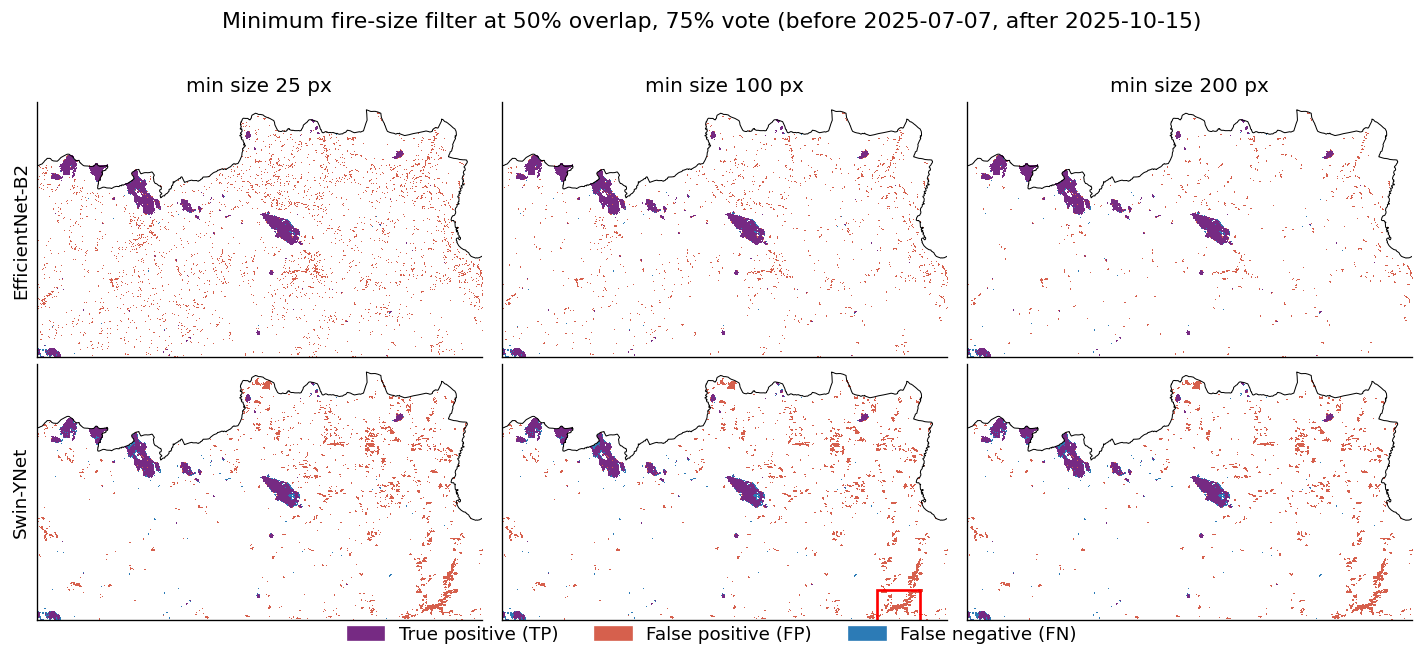

In [6]:
fig, axes = plt.subplots(len(MODELS), len(SHOW_SIZES), figsize=(4 * len(SHOW_SIZES), 2.6 * len(MODELS)))
axes = np.atleast_2d(axes)
for i, mdl in enumerate(MODELS):
    for j, ms in enumerate(SHOW_SIZES):
        ax = axes[i, j]
        ax.imshow(confusion_rgb(mdl, ms), extent=EXTENT, origin="upper", interpolation="nearest")
        PT.boundary.plot(ax=ax, color="black", linewidth=0.6)
        ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3])
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_title(f"min size {ms} px")
        if j == 0:
            ax.set_ylabel(MODEL_LABEL[mdl])
        if mdl == "swin_ynet" and ms == 100:
            l, b, r, top_ = swin_fp_top["utm_bbox"]
            pad = 2000
            rect = mpatches.Rectangle((l - pad, b - pad), (r - l) + 2 * pad, (top_ - b) + 2 * pad,
                                       fill=False, edgecolor="red", linewidth=1.6)
            ax.add_patch(rect)

handles = [mpatches.Patch(color=C_AGREE, label="True positive (TP)"),
           mpatches.Patch(color=C_FALSE, label="False positive (FP)"),
           mpatches.Patch(color=C_MISS, label="False negative (FN)")]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Minimum fire-size filter at 50% overlap, 75% vote "
             f"(before {BEFORE}, after {AFTER})", y=1.02)
plt.tight_layout()
plt.show()


*Observation.* The pattern matches `min_fire_size.ipynb`: EfficientNet-B2's
false positives are scattered specks that thin out steadily as the minimum
size rises from 25 to 200 pixels. Swin-YNet keeps a large false-positive
region near the southern edge of the tile (boxed) across every minimum size
shown, since the region is far above the 200-pixel cutoff and the size
filter cannot reach it. At this zoom the region already reads as elongated
and branching rather than a compact blob, which Section 4 examines more
closely. Section 3 ranks every cluster first, to confirm this is the largest
disagreement either model produces at this setting.


## 3. Ranking the largest error clusters

**Objective.** Tabulate and rank the connected FP and FN components for both
models at the reference setting (75% vote, 100-pixel minimum), to confirm
which disagreements are worth a closer look and which are comparatively
minor speckle.


In [7]:
rows = []
for mdl in MODELS:
    p = filtered_pred(mdl, MIN_SIZE)
    fp, fn = p & ~t, ~p & t
    for kind, mask in [("FP", fp), ("FN", fn)]:
        for c in top_components(mask, k=3):
            rows.append({"model": MODEL_LABEL[mdl], "type": kind, "area_ha": round(c["ha"], 1),
                         "area_px": c["px"], "lon_min": round(c["wgs84_bbox"][0], 4),
                         "lat_min": round(c["wgs84_bbox"][1], 4), "lon_max": round(c["wgs84_bbox"][2], 4),
                         "lat_max": round(c["wgs84_bbox"][3], 4)})
cluster_table = pd.DataFrame(rows).sort_values(["type", "area_ha"], ascending=[True, False]).reset_index(drop=True)
cluster_table


,model,type,area_ha,area_px,lon_min,lat_min,lon_max,lat_max
0,Swin-YNet,FN,100.2,10020,-7.5174,41.8373,-7.5023,41.8525
1,Swin-YNet,FN,84.6,8455,-7.7520,41.4568,-7.7328,41.4655
2,Swin-YNet,FN,70.6,7064,-7.7791,41.4616,-7.7678,41.4749
3,EfficientNet-B2,FN,45.1,4514,-7.7519,41.4569,-7.7408,41.4659
4,EfficientNet-B2,FN,45.1,4510,-7.8027,41.4573,-7.7861,41.4680
5,EfficientNet-B2,FN,43.2,4317,-7.0526,41.7342,-7.0363,41.7478
6,Swin-YNet,FP,614.3,61426,-6.6707,41.4512,-6.5911,41.4877
7,Swin-YNet,FP,294.8,29480,-6.6063,41.4835,-6.5594,41.5085
8,Swin-YNet,FP,246.1,24607,-6.6042,41.5287,-6.5691,41.5567
9,EfficientNet-B2,FP,35.7,3566,-6.5509,41.6159,-6.5311,41.6304


*Observation.* Swin-YNet's largest false positive (614 ha) is more than twice
the size of its next-largest cluster and over an order of magnitude larger
than any cluster either model produces elsewhere in the table. Every other FP
and FN cluster for both models, including all of EfficientNet's, falls under
50 ha, consistent with isolated misclassification rather than a single
systematic failure. This is why the standout cluster, rather than any of the
smaller ones, is the focus of the closer look and the Sentinel-2 check below.


## 4. Close-up review of the standout clusters

**Objective.** Crop the vote map and the ground truth around the standout
Swin-YNet false positive, and around one representative EfficientNet false
positive and one representative false negative, for a closer look at what
each model saw before disagreeing with the ground truth.


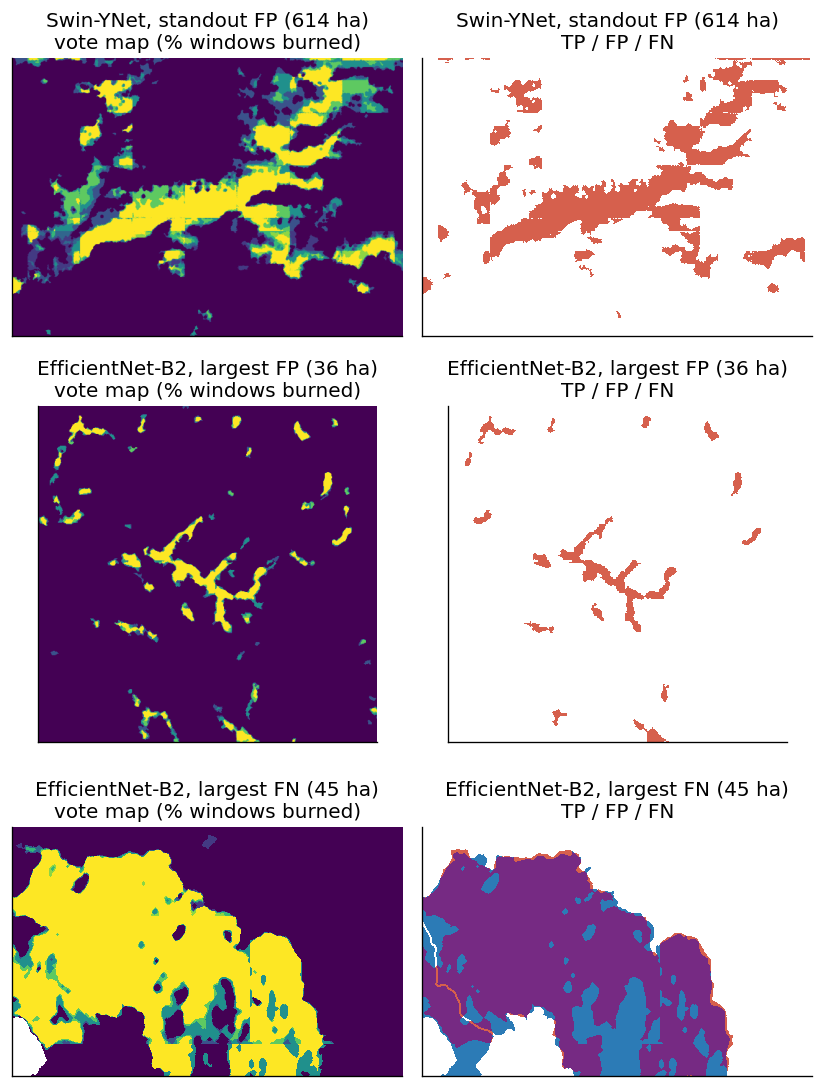

In [8]:
def crop_window(bbox, pad=1500):
    left, bottom, right, top_ = bbox
    left, bottom, right, top_ = left - pad, bottom - pad, right + pad, top_ + pad
    r0, c0 = rasterio.transform.rowcol(GRID_T, left, top_)
    r1, c1 = rasterio.transform.rowcol(GRID_T, right, bottom)
    r0, r1 = max(0, r0), min(GRID_SHAPE[0], r1)
    c0, c1 = max(0, c0), min(GRID_SHAPE[1], c1)
    return r0, r1, c0, c1

def show_cluster(mdl, bbox, label, ax_row):
    r0, r1, c0, c1 = crop_window(bbox)
    v = votes[mdl][r0:r1, c0:c1]
    gt = t[r0:r1, c0:c1]
    p = filtered_pred(mdl, MIN_SIZE)[r0:r1, c0:c1]
    cat = np.zeros(v.shape + (3,))
    cat[:] = mcolors.to_rgb("white")
    cat[p & gt] = mcolors.to_rgb(C_AGREE)
    cat[p & ~gt] = mcolors.to_rgb(C_FALSE)
    cat[~p & gt] = mcolors.to_rgb(C_MISS)

    ax_row[0].imshow(np.where(v == 255, np.nan, v), cmap="viridis", vmin=0, vmax=100)
    ax_row[0].set_title(f"{label}\nvote map (% windows burned)")
    ax_row[1].imshow(cat, interpolation="nearest")
    ax_row[1].set_title(f"{label}\nTP / FP / FN")
    for ax in ax_row:
        ax.set_xticks([]); ax.set_yticks([])

clusters_to_show = [
    ("swin_ynet", swin_fp_top["utm_bbox"], "Swin-YNet, standout FP (614 ha)"),
]
efn_p = filtered_pred("efficientnet_b2", MIN_SIZE)
efn_fp1 = top_components(efn_p & ~t, k=1)[0]
efn_fn1 = top_components(~efn_p & t, k=1)[0]
clusters_to_show.append(("efficientnet_b2", efn_fp1["utm_bbox"], f"EfficientNet-B2, largest FP ({efn_fp1['ha']:.0f} ha)"))
clusters_to_show.append(("efficientnet_b2", efn_fn1["utm_bbox"], f"EfficientNet-B2, largest FN ({efn_fn1['ha']:.0f} ha)"))

fig, axes = plt.subplots(len(clusters_to_show), 2, figsize=(7, 3.2 * len(clusters_to_show)))
axes = np.atleast_2d(axes)
for row, (mdl, bbox, label) in zip(axes, clusters_to_show):
    show_cluster(mdl, bbox, label, row)
plt.tight_layout()
plt.show()


*Observation.* The standout Swin-YNet cluster votes burned at a high,
spatially coherent percentage along a narrow, winding, branching shape, not
a compact blob. That shape is consistent with a river channel or stream
network rather than a fire scar or a forestry clearance, both of which would
follow terrain or field boundaries and read as more compact and rounded. A
plausible explanation is that the model is reacting to water, exposed
sediment, or a seasonal water-level change along this drainage line, rather
than to fire. The EfficientNet examples are smaller and more textured, with
the vote percentage varying within each crop, consistent with scattered
per-window disagreement at field- or patch-scale boundaries rather than one
coherent change. The largest EfficientNet false negative also shows a
genuine fire only partly detected (true positive over part of the burned
patch, false negative over the rest), pointing to under-detection at the
margins of a real fire rather than a missed detection of the whole event.
The river hypothesis for the Swin-YNet cluster is testable directly: Section
5 checks it against real Sentinel-2 imagery.


## 5. Verification against real Sentinel-2 imagery

**Purpose.** Pull true colour Sentinel-2 chips for the standout cluster, one
from around the before date and one from around the after date, via the CDSE
Process API (`utils/sentinel_hub.py`), to check by eye whether the flagged
area shows a real, visible change.

**Requires CDSE OAuth credentials.** Set `CDSE_CLIENT_ID` and
`CDSE_CLIENT_SECRET` as environment variables, or add a `cdse:` block to
`config.local.yaml` (see the `utils/sentinel_hub.py` module docstring for the
registration steps). Without credentials, the cell below raises a
`CDSEAuthError` with the setup instructions instead of producing images.


In [9]:
target_bbox = swin_fp_top["utm_bbox"]
pad = 1500
bbox_padded = (target_bbox[0] - pad, target_bbox[1] - pad, target_bbox[2] + pad, target_bbox[3] + pad)

try:
    img_before = fetch_truecolor(bbox_padded, BEFORE, bbox_crs="EPSG:32629")
    img_after = fetch_truecolor(bbox_padded, AFTER, bbox_crs="EPSG:32629")
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    axes[0].imshow(img_before); axes[0].set_title(f"before ({BEFORE} ± 5 d)")
    axes[1].imshow(img_after); axes[1].set_title(f"after ({AFTER} ± 5 d)")
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()
except CDSEAuthError as e:
    print(e)


No CDSE credentials found. Set CDSE_CLIENT_ID and CDSE_CLIENT_SECRET as environment variables, or add a `cdse:` block with client_id/client_secret to config.local.yaml. Register an OAuth client at https://shapps.dataspace.copernicus.eu/dashboard/#/account/settings (see utils/sentinel_hub.py module docstring for details).


*Observation.* Run this section once CDSE credentials are available. The
winding, branching shape in Section 4 is the working hypothesis that this
is a river or stream rather than a fire scar: confirm or rule it out
directly against the true colour chips. A river shows as a consistent,
narrow blue or turbid channel in both the before and after image, with no
darkening or loss of vegetation along its banks. A genuine fire, by
contrast, shows a dark, textured burn scar with visibly reduced vegetation
cover that appears in the after image but not the before image. If neither
pattern is clearly visible, also consider a cloud shadow or a harvested
field, and update this cell with the specific visual evidence once the
images are available.


## 6. Summary

EfficientNet-B2 and Swin-YNet fail in different ways at this setting (50%
overlap, 75% vote, 100-pixel minimum fire size). EfficientNet's disagreements
are small, scattered clusters, all under 50 ha, spread across the tile and
varying in vote percentage within each cluster. This pattern is consistent
with ordinary per-window classification noise at field or patch boundaries
rather than a systematic blind spot, and matches why the minimum-size filter
in `min_fire_size.ipynb` is so effective for this model: raising the cutoff
removes speckle without touching real fires.

Swin-YNet's error budget is dominated by one 614 ha false-positive region that
is more than twice the size of its next-largest cluster and well above even
the strictest 200-pixel cutoff tested, so no minimum-size filter in the range
considered removes it. Its high vote percentage, combined with its narrow,
winding, branching shape rather than a compact blob, points away from a
classification artefact and toward a real, contiguous feature in the input
scenes that follows a drainage line. The leading explanation is a river or
stream misread as burned, plausibly through dark water or exposed sediment
sharing some spectral characteristics with char; less likely alternatives are
a real burn the ICNF window does not record, or a non-fire land-cover change
such as forestry clearance or agricultural burning along the same line. The
true colour comparison in Section 5 is needed to confirm the river hypothesis
or rule it out before treating this region as either a labelling gap or a
genuine model weakness. EfficientNet's largest false negative, by contrast,
is a real fire detected over only part of its extent, suggesting the model's
boundary delineation is conservative rather than blind to the event.
